In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv(r'C:\Users\Pc\Documents\GitHub\autoinsightcs70\model_training\clean#1 (1).csv')
print(data.head())

   Unnamed: 0 Vehicle Type    Make                Model    Year      Price  \
0           0          Car  Toyota                 Axio  2008.0  7150000.0   
1           1          Car  Suzuki              Wagon R  2016.0  5690000.0   
2           2          Car  Toyota  VITZ SAFETY EDITION  2016.0        NaN   
3           3          Car  Suzuki           Alto Japan  2023.0  6590000.0   
4           4          Car   Honda             EK3 ViRs  2000.0        NaN   

   Milleage      District published date  \
0  178000.0       Colombo       2/1/2026   
1   79000.0        Ragama       2/7/2026   
2   85000.0        Chilaw       2/7/2026   
3    9900.0  Kiribathgoda       2/7/2026   
4     264.0         Kandy       2/7/2026   

                                         Vehicle URL  
0  https://riyasewana.com/buy/toyota-axio-sale-co...  
1  https://riyasewana.com/buy/suzuki-wagon-r-sale...  
2  https://riyasewana.com/buy/toyota-vitz-safety-...  
3  https://riyasewana.com/buy/suzuki-alto-japa

In [2]:
print(data.isnull().sum())

Unnamed: 0           0
Vehicle Type         0
Make                 0
Model               25
Year                42
Price             7096
Milleage          3986
District             1
published date       0
Vehicle URL          0
dtype: int64


In [3]:
print(data['Milleage'].describe())

count    2.969800e+04
mean     5.419231e+05
std      1.818768e+07
min      1.000000e+00
25%      6.600000e+04
50%      1.215000e+05
75%      1.740000e+05
max      1.234568e+09
Name: Milleage, dtype: float64


In [4]:

data = data[data['Price'] < 30000000].copy()
data = data[data['Milleage'] < 1000000].copy()

print('Rows after filtering: ' , data.shape[0])

Rows after filtering:  23430


In [5]:
def get_condition(year, milleage):
    if year < 2022:
        return 'Used'
    else:
        if pd.isnull(milleage):
            return 'Unknown'
        elif milleage < 5000:
            return 'Brand New'
        elif milleage <= 50000:
            return 'Recondition'
        else: 
            return 'Used'

# Create a new column 'Condition' based on the 'Year' and 'Milleage' columns    
data['Condition'] = data.apply(lambda row: get_condition(row['Year'], row['Milleage']), axis=1)   

print (data['Condition'].value_counts())
print(data[['Year', 'Milleage', 'Condition']].head())

Condition
Used           20926
Recondition     1398
Brand New       1106
Name: count, dtype: int64
     Year  Milleage    Condition
0  2008.0  178000.0         Used
1  2016.0   79000.0         Used
3  2023.0    9900.0  Recondition
5  2011.0  156100.0         Used
6  2013.0   76000.0         Used


In [6]:
data.to_csv('dataset_with_condition.csv', index=False)
print('Saved! Columns: ', data.columns.tolist())

Saved! Columns:  ['Unnamed: 0', 'Vehicle Type', 'Make', 'Model', 'Year', 'Price', 'Milleage', 'District', 'published date', 'Vehicle URL', 'Condition']


In [7]:
data1 = pd.read_csv(r'C:\Users\Pc\Documents\GitHub\autoinsightcs70\model_training\dataset_with_condition.csv')
print(data1.isnull().sum())

Unnamed: 0         0
Vehicle Type       0
Make               0
Model             15
Year              23
Price              0
Milleage           0
District           0
published date     0
Vehicle URL        0
Condition          0
dtype: int64


In [1]:
import pandas as pd

# Read the CSV file
df = pd.read_csv(r'C:\Users\Pc\Documents\GitHub\autoinsightcs70\model_training\dataset_with_condition.csv')

print("Original Model column (first 10 rows):")
print(df['Model'].head(10))

# Convert Model column to uppercase
df['Model'] = df['Model'].str.upper()

print("\nModified Model column (first 10 rows):")
print(df['Model'].head(10))

# Save to a new file
df.to_csv(r'C:\Users\Pc\Documents\GitHub\autoinsightcs70\model_training\dataset_with_condition_uppercase.csv', index=False)

print("\n File saved as 'dataset_with_condition_uppercase.csv'")
print(f"\n Total rows: {len(df)}")
print(f"Unique models: {df['Model'].nunique()}")

Original Model column (first 10 rows):
0                Axio
1             Wagon R
2          Alto Japan
3            Alto K10
4                   6
5                Alto
6    Spacia Custom Xs
7                Duet
8          Vitz KSP90
9         Corolla 141
Name: Model, dtype: object

Modified Model column (first 10 rows):
0                AXIO
1             WAGON R
2          ALTO JAPAN
3            ALTO K10
4                   6
5                ALTO
6    SPACIA CUSTOM XS
7                DUET
8          VITZ KSP90
9         COROLLA 141
Name: Model, dtype: object

 File saved as 'dataset_with_condition_uppercase.csv'

 Total rows: 23430
Unique models: 4211


In [4]:

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import joblib
import warnings
warnings.filterwarnings('ignore')


# 1. DATA LOADING & CLEANING


def load_and_clean(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Drop unnamed index column if present
    df = df.drop(columns=[c for c in df.columns if 'Unnamed' in c], errors='ignore')

    # Drop rows with missing Model or Year (can't meaningfully use them)
    df = df.dropna(subset=['Model', 'Year', 'Price', 'Milleage'])

    # Type casting
    df['Year'] = df['Year'].astype(int)
    df['published date'] = pd.to_datetime(df['published date'])

    # Remove extreme outliers (already done in notebook, kept here for safety)
    df = df[df['Price'] < 30000000]
    df = df[df['Milleage'] < 1000000]

    # Sort for lag feature correctness — CRITICAL
    df = df.sort_values(['Make', 'Model', 'published date']).reset_index(drop=True)

    return df


# 2. FEATURE ENGINEERING


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df['post_year'] = df['published date'].dt.year
    df['Car_Age'] = df['post_year'] - df['Year']
    df['month'] = df['published date'].dt.month
    df['week'] = df['published date'].dt.isocalendar().week.astype(int)
    df['day_of_year'] = df['published date'].dt.dayofyear

    # Lag features (within Make+Model group) — lag_1 = last known price
    df['lag_1'] = df.groupby(['Make', 'Model'])['Price'].shift(1)
    df['lag_2'] = df.groupby(['Make', 'Model'])['Price'].shift(2)

    # Rolling mean of last 3 prices for the same Make+Model
    df['rolling_mean_3'] = (
        df.groupby(['Make', 'Model'])['Price']
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

    # Drop rows where lag features are NaN (first entry per Make+Model)
    df = df.dropna(subset=['lag_1', 'lag_2', 'rolling_mean_3'])

    return df


# 3. MODEL TRAINING


NUMERIC_FEATURES = [
    'Car_Age',
    'month',
    'week',
    'day_of_year',
    'lag_1',
    'lag_2',
    'rolling_mean_3',
]
CATEGORICAL_FEATURES = ['Make', 'Model']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def train_model(df: pd.DataFrame):
    df = df.copy()

    # Encode categoricals for LightGBM native handling
    for col in CATEGORICAL_FEATURES:
        df[col] = df[col].astype('category')

    # Temporal train/test split — last 30 days as test (mimics production)
    split_date = df['published date'].max() - pd.Timedelta(days=30)
    train = df[df['published date'] <= split_date]
    test  = df[df['published date'] >  split_date]

    X_train, y_train = train[ALL_FEATURES], train['Price']
    X_test,  y_test  = test[ALL_FEATURES],  test['Price']

    print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

    model = lgb.LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        verbose=-1,
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(stopping_rounds=150, verbose=False),
            lgb.log_evaluation(period=200),
        ]
    )

    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    mape  = mean_absolute_percentage_error(y_test, preds) * 100

    print(f"\n{'='*45}")
    print(f"  Test MAE  : LKR {mae:,.0f}")
    print(f"  Test MAPE : {mape:.2f}%")
    print(f"{'='*45}\n")

    return model, df



# 4. KEY FIX: USER-DATE BASED PREDICTION


def predict_from_user_date(
    model,
    df: pd.DataFrame,
    make: str,
    model_name: str,
    user_query_date: str,
    manufacture_year: int,
    horizon_days: int = 7,   # 7 = next week, 28 = next month
    verbose: bool = True,     # Control output verbosity
) -> dict:
  

    query_date = pd.Timestamp(user_query_date)

    # Step 1: Get the most recent known price for this Make+Model
    subset = df[
        (df['Make'].str.lower() == make.lower()) &
        (df['Model'].str.lower() == model_name.lower()) &
        (df['published date'] <= query_date)
    ].sort_values('published date')

    if subset.empty:
        # Fallback: use any listing for this Make+Model regardless of date
        subset = df[
            (df['Make'].str.lower() == make.lower()) &
            (df['Model'].str.lower() == model_name.lower())
        ].sort_values('published date')

    if subset.empty:
        raise ValueError(f"No data found for {make} {model_name}. "
                         f"Check spelling or add data for this vehicle.")

    last_known_price    = subset.iloc[-1]['Price']
    second_last_price   = subset.iloc[-2]['Price'] if len(subset) >= 2 else last_known_price
    rolling_mean_price  = subset['Price'].tail(3).mean()

    if verbose:
        print(f"\n  Vehicle      : {make} {model_name} ({manufacture_year})")
        print(f"  Query Date   : {query_date.date()}")
        print(f"  Last Known Price (as of query date): LKR {last_known_price:,.0f}")
        print(f"  Forecasting  : {horizon_days} days ahead\n")

    # Step 2: Build a synthetic "current" row using user-supplied vehicle info
    car_age = query_date.year - manufacture_year

    current_row = {
        'Make'             : make,
        'Model'            : model_name,
        'Car_Age'          : car_age,
        'lag_1'            : last_known_price,
        'lag_2'            : second_last_price,
        'rolling_mean_3'   : rolling_mean_price,
    }

    # Step 3: Iterative weekly rollout from user_query_date
    predictions = {}
    future_row  = current_row.copy()
    future_date = query_date

    steps = max(1, horizon_days // 7)  # weekly steps

    for _ in range(1, steps + 1):
        # Calculate the start and end of this week period
        week_start = future_date + pd.Timedelta(days=7)
        week_end = week_start + pd.Timedelta(days=6)
        
        future_date = week_start

        future_row['month']       = future_date.month
        future_row['week']        = future_date.isocalendar()[1]
        future_row['day_of_year'] = future_date.timetuple().tm_yday

        # Build prediction dataframe with proper dtypes
        pred_df = pd.DataFrame([future_row])
        for col in CATEGORICAL_FEATURES:
            # Use the full category set from training data
            known_cats = df[col].astype('category').cat.categories
            pred_df[col] = pd.Categorical(pred_df[col], categories=known_cats)

        price_pred = model.predict(pred_df[ALL_FEATURES])[0]

        # Store with date range to show price is constant for the entire week
        date_range = f"{week_start.strftime('%Y-%m-%d')} to {week_end.strftime('%Y-%m-%d')}"
        predictions[date_range] = round(price_pred, 2)

        # Update lag for next iteration (the key to chained forecasting)
        future_row['lag_2']           = future_row['lag_1']
        future_row['lag_1']           = price_pred
        future_row['rolling_mean_3']  = np.mean([
            future_row['lag_1'],
            future_row['lag_2'],
            rolling_mean_price
        ])

    return {
        'make'             : make,
        'model'            : model_name,
        'query_date'       : query_date.strftime('%Y-%m-%d'),
        'current_price'    : last_known_price,
        'predictions'      : predictions,
    }



# 5. CONVENIENCE WRAPPERS


def predict_next_week(model, df, make, model_name, user_query_date,
                      manufacture_year):
    return predict_from_user_date(
        model, df, make, model_name, user_query_date,
        manufacture_year, horizon_days=7
    )


def predict_next_month(model, df, make, model_name, user_query_date,
                       manufacture_year):
    return predict_from_user_date(
        model, df, make, model_name, user_query_date,
        manufacture_year, horizon_days=28
    )



# 7. MAIN — TRAIN + GENERATE CSV + DEMO


def generate_vehicle_statistics_csv(
    model,
    df: pd.DataFrame,
    raw_df: pd.DataFrame,
    output_path: str = 'vehicle_statistics_with_predictions.csv'
):
    print("\n" + "="*60)
    print("  GENERATING VEHICLE STATISTICS CSV")
    print("="*60)
    
    # Group by Make, Model, Year and calculate statistics
    vehicle_groups = raw_df.groupby(['Make', 'Model', 'Year']).agg({
        'Price': 'mean',
        'Milleage': 'mean'
    }).reset_index()
    
    vehicle_groups.columns = ['Make', 'Model', 'Year', 'Average_Price', 'Average_Mileage']
    
    # Calculate predicted next week price for each vehicle
    print(f"\n  Calculating predictions for {len(vehicle_groups)} vehicles...")
    predicted_prices = []
    
    for idx, row in vehicle_groups.iterrows():
        try:
            # Use the most recent date in the dataset as reference
            latest_date = df['published date'].max()
            
            result = predict_from_user_date(
                model, df,
                make=row['Make'],
                model_name=row['Model'],
                user_query_date=latest_date,
                manufacture_year=int(row['Year']),
                horizon_days=7,
                verbose=False  # Suppress detailed output
            )
            
            # Get the first predicted price (next week)
            first_prediction = list(result['predictions'].values())[0]
            predicted_prices.append(first_prediction)
            
            if (idx + 1) % 50 == 0:
                print(f"    Processed {idx + 1}/{len(vehicle_groups)} vehicles...")
                
        except Exception as e:
            # If prediction fails, use average price
            predicted_prices.append(row['Average_Price'])
    
    vehicle_groups['Predicted_Next_Week_Price'] = predicted_prices
    
    # Round values for cleaner output
    vehicle_groups['Average_Price'] = vehicle_groups['Average_Price'].round(0).astype(int)
    vehicle_groups['Average_Mileage'] = vehicle_groups['Average_Mileage'].round(0).astype(int)
    vehicle_groups['Predicted_Next_Week_Price'] = vehicle_groups['Predicted_Next_Week_Price'].round(0).astype(int)
    
    # Sort by Make, Model, Year
    vehicle_groups = vehicle_groups.sort_values(['Make', 'Model', 'Year']).reset_index(drop=True)
    
    # Save to CSV
    vehicle_groups.to_csv(output_path, index=False)
    
    print(f"\n CSV file generated successfully!")
    print(f"Location: {output_path}")
    print(f"Total vehicles: {len(vehicle_groups)}")
    print(f"\n  Sample output (first 5 rows):")
    print(vehicle_groups.head().to_string(index=False))
    print("\n" + "="*60)
    
    return vehicle_groups



# 6. MAIN — TRAIN + DEMO

if __name__ == '__main__':
    CSV_PATH = r'C:\Users\Pc\Documents\GitHub\autoinsightcs70\model_training\dataset_with_condition_uppercase.csv'
    
    print("Loading data...")
    raw_df = load_and_clean(CSV_PATH)
    
    print("Engineering features...")
    eng_df = engineer_features(raw_df)
    
    print("Training model...")
    trained_model, eng_df = train_model(eng_df)
    
    # Save model for API/backend use
    joblib.dump(trained_model, 'lgbm_vehicle_price_model.pkl')
    print("Model saved to lgbm_vehicle_price_model.pkl\n")
    
    # ── GENERATE CSV WITH VEHICLE STATISTICS
    vehicle_stats = generate_vehicle_statistics_csv(
        trained_model, eng_df, raw_df,
        output_path='vehicle_statistics_with_predictions.csv'
    )
    
    # ── DEMO: User inputs only Make, Model, and Year
    #          System automatically uses the date and finds prices
    print("\n" + "="*60)
    print("  DEMO: VEHICLE PRICE PREDICTION")
    print("="*60)
    
    USER_QUERY_DATE  = '2026-03-01'   # ← This is the date the USER opens the app
    MAKE             = 'Honda'
    MODEL_NAME       = 'VEZEL Z PREMIUM'
    MANUFACTURE_YEAR = 2025
    
    print("\n" + "="*50)
    print("  NEXT WEEK FORECAST")
    print("="*50)
    
    week_result = predict_next_week(
        trained_model, eng_df,
        MAKE, MODEL_NAME, USER_QUERY_DATE,
        MANUFACTURE_YEAR
    )
    
    print(f"\n  Current Price (Today): LKR {week_result['current_price']:>15,.0f}")
    print(f"  (This price is valid for the next 7 days)\n")
    print(f"  Predicted Prices (Price remains constant for entire week):")
    
    for date_range, price in week_result['predictions'].items():
        print(f"  {date_range}  →  LKR {price:>12,.0f}")
    
    print("\n" + "="*50)
    print("  NEXT MONTH FORECAST (Weekly Steps)")
    print("="*50)
    
    month_result = predict_next_month(
        trained_model, eng_df,
        MAKE, MODEL_NAME, USER_QUERY_DATE,
        MANUFACTURE_YEAR
    )
    
    print(f"\n  Current Price (Today): LKR {month_result['current_price']:>15,.0f}")
    print(f"  (This price is valid for the next 7 days)\n")
    print(f"  Predicted Prices (Price remains constant for entire week):")
    
    for date_range, price in month_result['predictions'].items():
        print(f"  {date_range}  →  LKR {price:>12,.0f}")
    
    print("\n" + "="*60)

    

Loading data...
Engineering features...
Training model...
Training samples: 6291 | Test samples: 11261
[200]	valid_0's l2: 3.27242e+12
[400]	valid_0's l2: 3.27586e+12

  Test MAE  : LKR 920,510
  Test MAPE : 23.94%

Model saved to lgbm_vehicle_price_model.pkl


  GENERATING VEHICLE STATISTICS CSV

  Calculating predictions for 8674 vehicles...
    Processed 100/8674 vehicles...
    Processed 250/8674 vehicles...
    Processed 300/8674 vehicles...
    Processed 400/8674 vehicles...
    Processed 450/8674 vehicles...
    Processed 550/8674 vehicles...
    Processed 600/8674 vehicles...
    Processed 650/8674 vehicles...
    Processed 850/8674 vehicles...
    Processed 950/8674 vehicles...
    Processed 1050/8674 vehicles...
    Processed 1150/8674 vehicles...
    Processed 1200/8674 vehicles...
    Processed 1350/8674 vehicles...
    Processed 1400/8674 vehicles...
    Processed 1450/8674 vehicles...
    Processed 1600/8674 vehicles...
    Processed 1700/8674 vehicles...
    Processed 18

In [ ]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('dataset_with_condition.csv')

print("Original Model column (first 10 rows):")
print(df['Model'].head(10))

# Extract only the first word from the Model column AND convert to uppercase
df['Model'] = df['Model'].astype(str).str.split().str[0].str.upper()

print("\nModified Model column (first 10 rows):")
print(df['Model'].head(10))

# Save to a NEW file (not overwriting the original)
df.to_csv('dataset_with_model_first_name.csv', index=False)

print("\n File saved as 'dataset_with_model_first_name.csv'")
print(f"\nUnique models after extraction ({len(df['Model'].unique())} unique models):")
print(sorted(df['Model'].unique()))

Original Model column (first 10 rows):
0                Axio
1             Wagon R
2          Alto Japan
3            Alto K10
4                   6
5                Alto
6    Spacia Custom Xs
7                Duet
8          Vitz KSP90
9         Corolla 141
Name: Model, dtype: object

Modified Model column (first 10 rows):
0       AXIO
1      WAGON
2       ALTO
3       ALTO
4          6
5       ALTO
6     SPACIA
7       DUET
8       VITZ
9    COROLLA
Name: Model, dtype: object

✓ File saved as 'dataset_with_model_first_name.csv'

Unique models after extraction (1130 unique models):
['#REF!', '-GLA', '.', '10', '100', '102', '103', '104', '106', '107', '110', '1100', '113', '115', '116', '118I', '121', '1300', '135DL', '14', '141', '150', '155', '156', '1613', '162', '180', '182', '2', '20', '203', '206', '207', '208', '218I', '225XE', '240', '250D', '260', '3', '300', '3008', '300C', '304', '305', '305GL', '306', '307', '316I', '318', '318I', '320D', '320DE90', '320I', '320S', '323', 

In [4]:
import pandas as pd

# Read the CSV file with first names
df = pd.read_csv('dataset_with_model_first_name.csv')

print("Before correction:")
print(df['Model'].value_counts().head(20))

# Replace WAGON with WAGON R
df['Model'] = df['Model'].replace('WAGON', 'WAGON R')

print("\nAfter correction:")
print(df['Model'].value_counts().head(20))

# Save back to the same file
df.to_csv('dataset_with_model_first_name.csv', index=False)

print("\n✓ File updated successfully!")
print(f"\nUnique models after correction ({len(df['Model'].unique())} unique models):")
print(sorted(df['Model'].unique()))

Before correction:
Model
WAGON      1103
ALTO        873
VITZ        831
VEZEL       628
COROLLA     612
EVERY       509
FIT         504
AXIO        490
AQUA        487
SWIFT       439
MARUTI      408
PREMIO      389
LANCER      332
ALLION      316
PRIUS       291
YARIS       280
TOWNACE     279
VANETTE     277
PANDA       273
CIVIC       259
Name: count, dtype: int64

After correction:
Model
WAGON R    1103
ALTO        873
VITZ        831
VEZEL       628
COROLLA     612
EVERY       509
FIT         504
AXIO        490
AQUA        487
SWIFT       439
MARUTI      408
PREMIO      389
LANCER      332
ALLION      316
PRIUS       291
YARIS       280
TOWNACE     279
VANETTE     277
PANDA       273
CIVIC       259
Name: count, dtype: int64

✓ File updated successfully!

Unique models after correction (1130 unique models):
['#REF!', '-GLA', '.', '10', '100', '102', '103', '104', '106', '107', '110', '1100', '113', '115', '116', '118I', '121', '1300', '135DL', '14', '141', '150', '155', '156', '

DUPLICATE DETECTION USING URLs

Using column: 'Vehicle URL' for duplicate detection

SUMMARY
Total records: 23430
Unique URLs: 23430
Duplicate URL entries found: 0

 No duplicate URLs found! Dataset is clean.

GENERATING VISUALIZATIONS


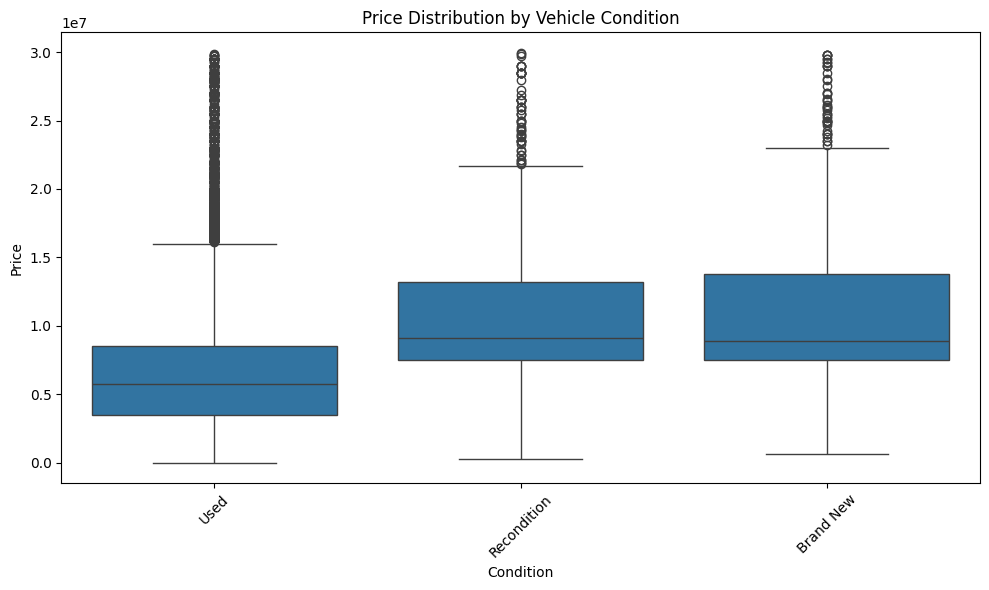

Saved: price_by_condition.png


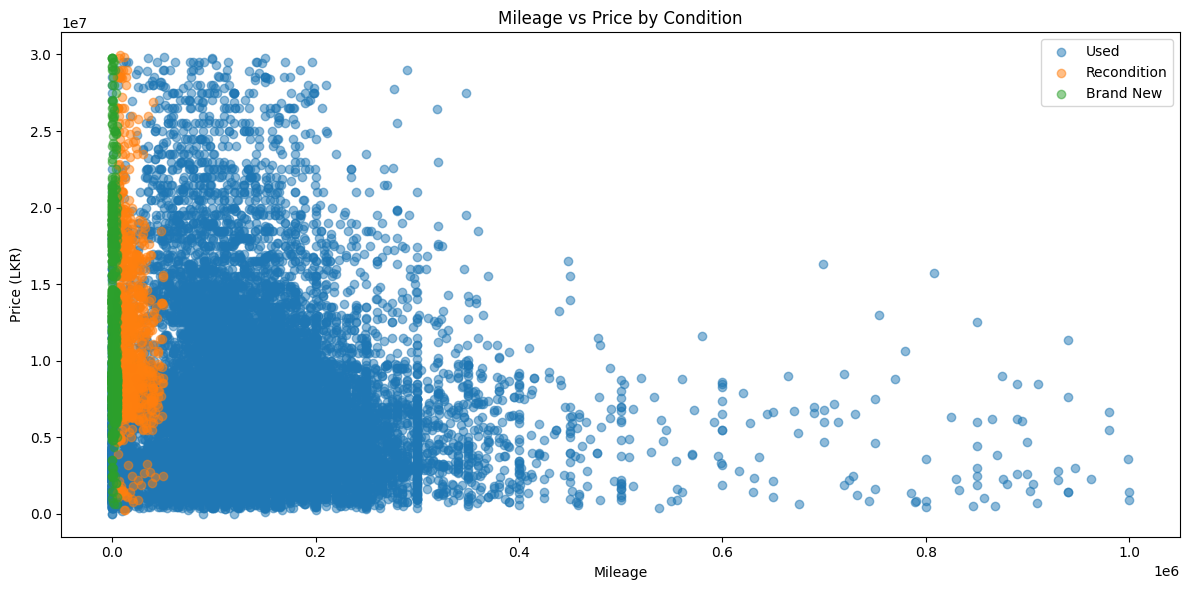

Saved: mileage_vs_price.png


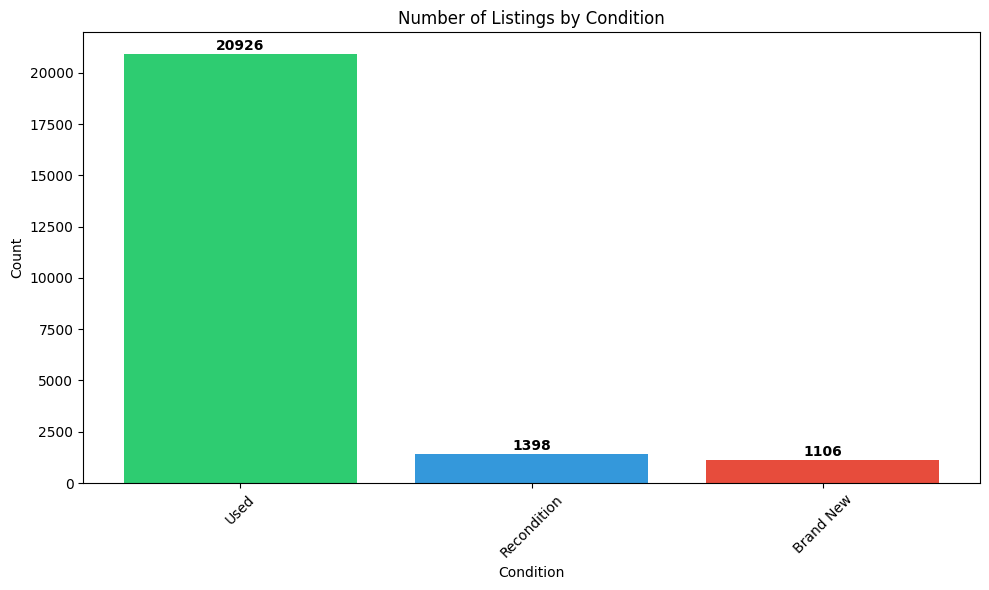

Saved: listings_by_condition.png

 Data quality checks complete!


In [ ]:
# Data Quality Checks - Using URL for Duplicate Detection
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load dataset
data1 = pd.read_csv(r'C:\Users\Pc\Documents\GitHub\autoinsightcs70\model_training\dataset_with_condition.csv')

print("="*70)
print("DUPLICATE DETECTION USING URLs")
print("="*70)

# Check if URL column exists
url_columns = [col for col in data1.columns if 'url' in col.lower()]

if url_columns:
    url_col = url_columns[0]  # Use the first URL column found
    print(f"\nUsing column: '{url_col}' for duplicate detection")
    
    # Check for duplicate URLs (exact same listing)
    url_duplicates = data1[data1.duplicated(subset=[url_col], keep=False)]
    
    print(f"\n{'='*70}")
    print("SUMMARY")
    print(f"{'='*70}")
    print(f"Total records: {len(data1)}")
    print(f"Unique URLs: {data1[url_col].nunique()}")
    print(f"Duplicate URL entries found: {len(url_duplicates)}")
    print(f"{'='*70}")
    
    if len(url_duplicates) > 0:
        print(f"\n WARNING: {len(url_duplicates)} duplicate URLs found!")
        print("\nSample duplicate URLs (first 10):")
        print(url_duplicates[[url_col, 'Make', 'Model', 'Year', 'Price']].head(10).to_string(index=False))
    else:
        print("\n No duplicate URLs found! Dataset is clean.")
    
    # Remove URL duplicates for visualizations
    data1 = data1.drop_duplicates(subset=[url_col], keep='first')
    
else:
    print("\n WARNING: No URL column found in dataset!")
    print(f"Available columns: {data1.columns.tolist()}")

# Visualizations using cleaned data
print(f"\n{'='*70}")
print("GENERATING VISUALIZATIONS")
print(f"{'='*70}")

# Price distribution by condition
plt.figure(figsize=(10, 6))
sns.boxplot(data=data1, x='Condition', y='Price')
plt.title('Price Distribution by Vehicle Condition')
plt.xticks(rotation=45)
plt.tight_layout() #automatically adjusts the padding to prevent overlap
plt.savefig('price_by_condition.png')
plt.show()
print("Saved: price_by_condition.png")

# Mileage vs Price correlation by condition
plt.figure(figsize=(12, 6))
for condition in data1['Condition'].unique():
    subset = data1[data1['Condition'] == condition]
    plt.scatter(subset['Milleage'], subset['Price'], label=condition, alpha=0.5)
plt.xlabel('Mileage')
plt.ylabel('Price (LKR)')
plt.legend() #this command automatically creates the color key based on the labels provided in the scatter plot
plt.title('Mileage vs Price by Condition')
plt.tight_layout()
plt.savefig('mileage_vs_price.png')
plt.show()
print("Saved: mileage_vs_price.png")

# Additional: Listings per condition
plt.figure(figsize=(10, 6))
condition_counts = data1['Condition'].value_counts()
plt.bar(condition_counts.index, condition_counts.values, color=['#2ecc71', '#3498db', '#e74c3c', '#95a5a6'])
plt.title('Number of Listings by Condition')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
for i, v in enumerate(condition_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('listings_by_condition.png')
plt.show()
print("Saved: listings_by_condition.png")

print(f"\n{'='*70}")
print(" Data quality checks complete!")
print(f"{'='*70}")

Total Vezel listings found: 628

Unique Vezel variants:
Model
Vezel                        239
Vezel Z                       46
Vezel Z Grade                 35
Vezel Z Play                  32
Vezel Z Premium               28
                            ... 
Vezel Z Grade Import           1
Vezel X Limited                1
VEZEL Z PLAY                   1
VEZEL Play                     1
VEZEL Z PLAY PREMIUM PLUS      1
Name: count, Length: 83, dtype: int64


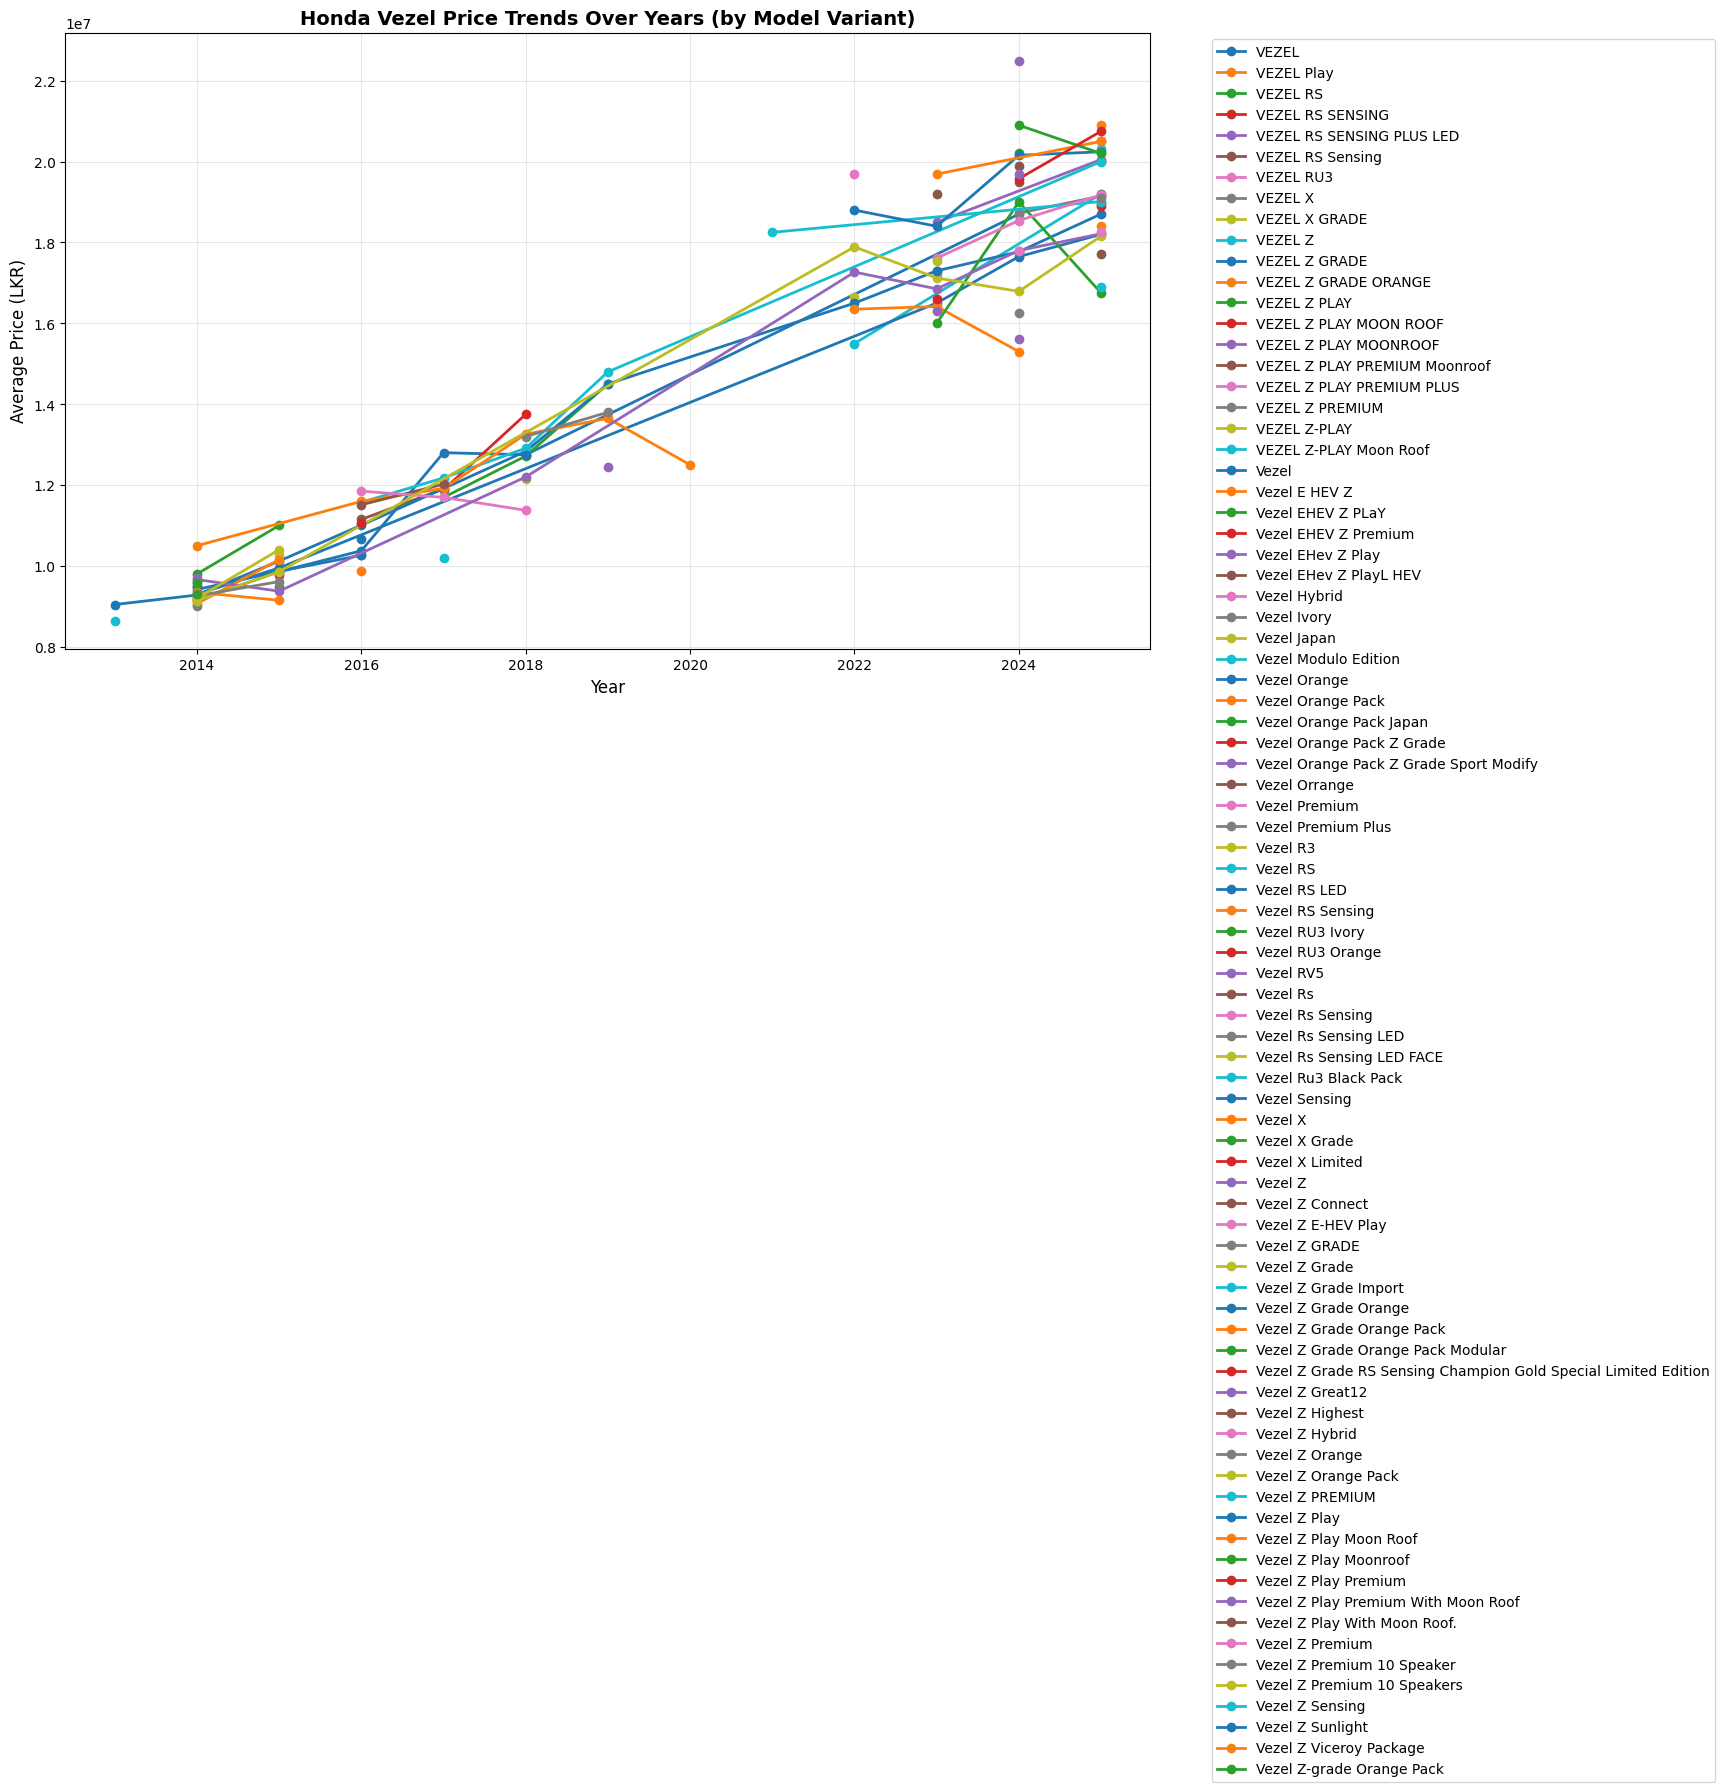


 Graph saved as 'vezel_price_trends.png'

VEZEL PRICE SUMMARY BY VARIANT

VEZEL:
  Count: 16
  Price range: LKR 8,600,000 - 18,700,000
  Average: LKR 10,484,375

VEZEL Play:
  Count: 1
  Price range: LKR 20,900,000 - 20,900,000
  Average: LKR 20,900,000

VEZEL RS:
  Count: 7
  Price range: LKR 11,500,000 - 14,500,000
  Average: LKR 12,532,857

VEZEL RS SENSING:
  Count: 7
  Price range: LKR 11,450,000 - 13,750,000
  Average: LKR 12,148,571

VEZEL RS SENSING PLUS LED:
  Count: 1
  Price range: LKR 12,450,000 - 12,450,000
  Average: LKR 12,450,000

VEZEL RS Sensing:
  Count: 3
  Price range: LKR 11,150,000 - 11,985,000
  Average: LKR 11,653,333

VEZEL RU3:
  Count: 1
  Price range: LKR 9,750,000 - 9,750,000
  Average: LKR 9,750,000

VEZEL X:
  Count: 1
  Price range: LKR 16,250,000 - 16,250,000
  Average: LKR 16,250,000

VEZEL X GRADE:
  Count: 1
  Price range: LKR 16,650,000 - 16,650,000
  Average: LKR 16,650,000

VEZEL Z:
  Count: 3
  Price range: LKR 15,500,000 - 20,500,000
  Average

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
data = pd.read_csv(r'C:\Users\Pc\Documents\GitHub\autoinsightcs70\model_training\dataset_with_condition.csv')

# Filter for Vezel models only
vezel_data = data[data['Model'].str.contains('VEZEL', case=False, na=False)].copy()

print(f"Total Vezel listings found: {len(vezel_data)}")
print(f"\nUnique Vezel variants:")
print(vezel_data['Model'].value_counts())

# Group by Model and Year, calculate average price
vezel_price_by_year = vezel_data.groupby(['Model', 'Year'])['Price'].mean().reset_index()

# Create the line graph
plt.figure(figsize=(14, 8))

# Plot a line for each Vezel variant
for model in vezel_price_by_year['Model'].unique():
    model_data = vezel_price_by_year[vezel_price_by_year['Model'] == model]
    plt.plot(model_data['Year'], model_data['Price'], marker='o', label=model, linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (LKR)', fontsize=12)
plt.title('Honda Vezel Price Trends Over Years (by Model Variant)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('vezel_price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Graph saved as 'vezel_price_trends.png'")

# Print summary statistics
print(f"\n{'='*60}")
print("VEZEL PRICE SUMMARY BY VARIANT")
print(f"{'='*60}")
for model in sorted(vezel_data['Model'].unique()):
    model_subset = vezel_data[vezel_data['Model'] == model]
    print(f"\n{model}:")
    print(f"  Count: {len(model_subset)}")
    print(f"  Price range: LKR {model_subset['Price'].min():,.0f} - {model_subset['Price'].max():,.0f}")
    print(f"  Average: LKR {model_subset['Price'].mean():,.0f}")

Total Raize listings found: 235

Unique Raize variants:
Model
Raize                          87
Raize Z Grade                  32
Raize Z                        13
Raize Hybrid                    9
RAIZE                           9
Raize Z Grade Hybrid            7
Raize Z Hybrid                  6
Raize G Grade                   5
RAIZE Z GRADE                   4
Raize Z Premium                 3
Raize Hybrid Z                  3
RAIZE G                         3
Raize X Grade                   3
RAIZE Z                         2
Raize G Turbo                   2
Raize Z Hybrid 1200             2
Raize G                         2
Raize Z Limited                 2
Raize Z Grade Turbo             2
Raize 1000cc Turbo              1
Raize Hybrid G Grade            1
RAIZE Z Japan                   1
Raize 1200 Hybrid               1
RAIZE Z HYBRID                  1
RAIZE TURBO                     1
Raize Z Grade Apple Carplay     1
Raize Z Grade 1 2L              1
RAIZE Hybrid Z Grade

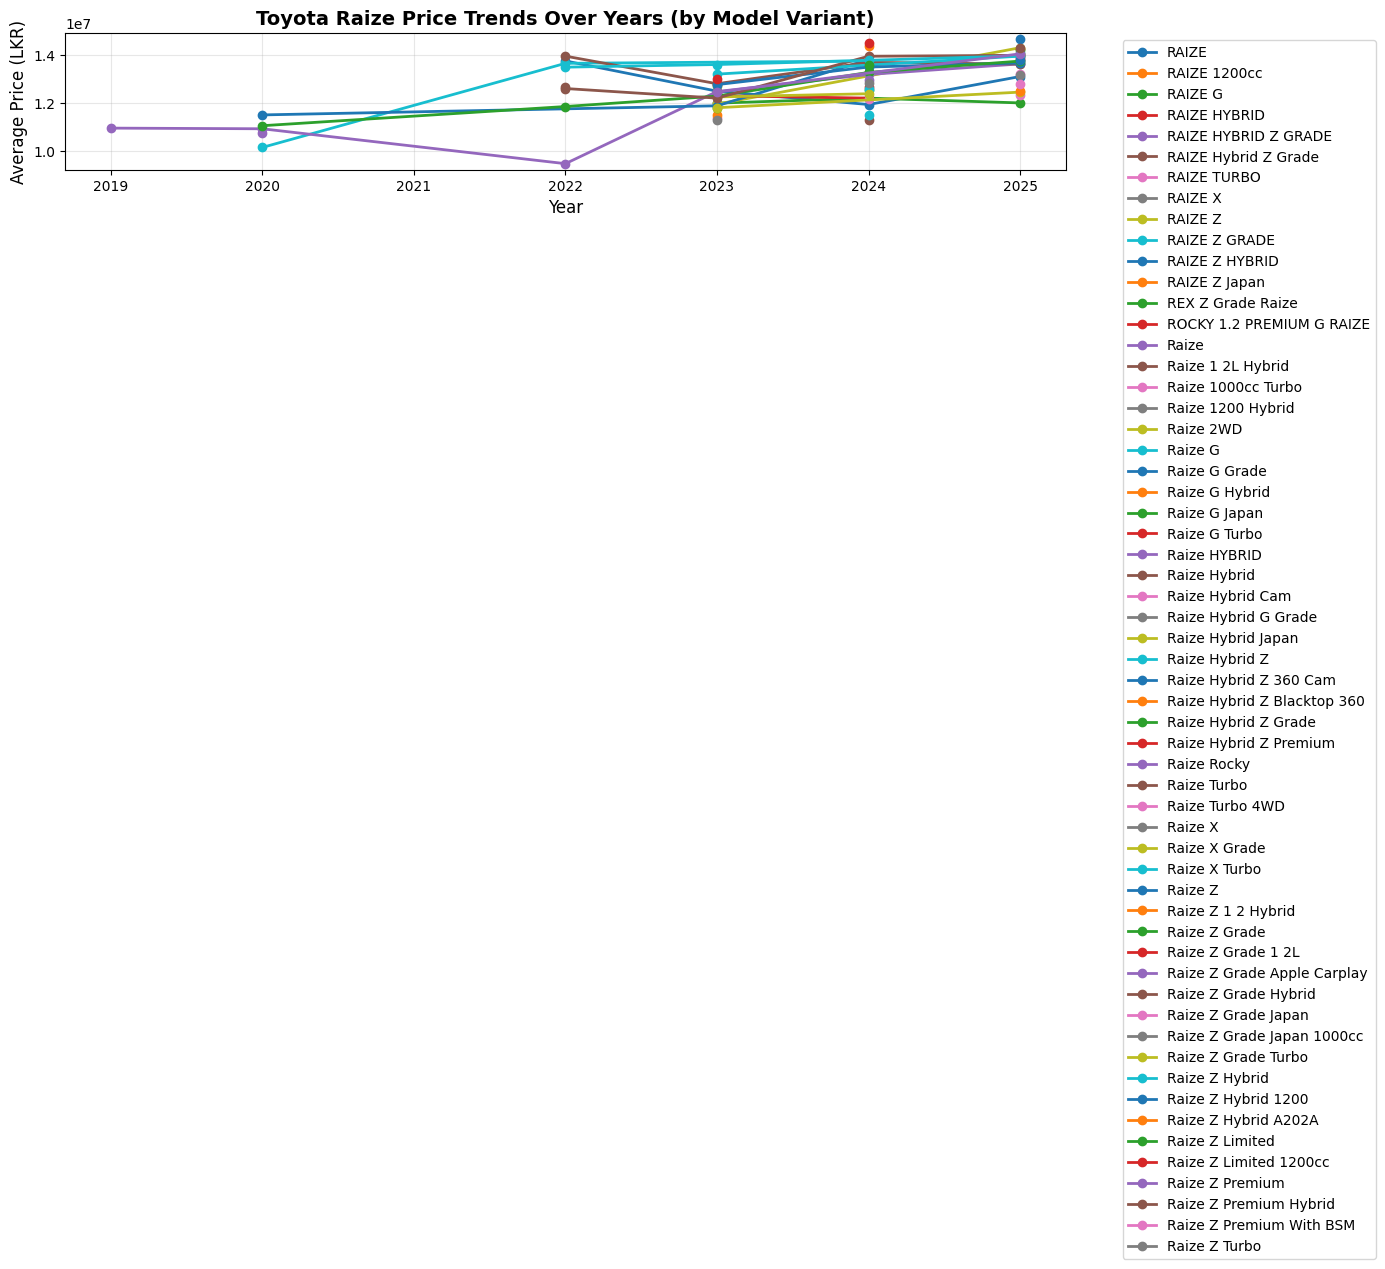


✓ Graph saved as 'raize_price_trends.png'

RAIZE PRICE SUMMARY BY VARIANT

RAIZE:
  Count: 9
  Price range: LKR 11,390,000 - 13,750,000
  Average: LKR 12,647,778

RAIZE 1200cc:
  Count: 1
  Price range: LKR 12,390,000 - 12,390,000
  Average: LKR 12,390,000

RAIZE G:
  Count: 3
  Price range: LKR 11,990,000 - 12,200,000
  Average: LKR 12,063,333

RAIZE HYBRID:
  Count: 1
  Price range: LKR 13,300,000 - 13,300,000
  Average: LKR 13,300,000

RAIZE HYBRID Z GRADE:
  Count: 1
  Price range: LKR 13,900,000 - 13,900,000
  Average: LKR 13,900,000

RAIZE Hybrid Z Grade:
  Count: 1
  Price range: LKR 12,650,000 - 12,650,000
  Average: LKR 12,650,000

RAIZE TURBO:
  Count: 1
  Price range: LKR 11,390,000 - 11,390,000
  Average: LKR 11,390,000

RAIZE X:
  Count: 1
  Price range: LKR 11,990,000 - 11,990,000
  Average: LKR 11,990,000

RAIZE Z:
  Count: 2
  Price range: LKR 11,950,000 - 14,300,000
  Average: LKR 13,125,000

RAIZE Z GRADE:
  Count: 4
  Price range: LKR 10,145,000 - 14,000,000
  Avera

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
data = pd.read_csv(r'C:\Users\Pc\Documents\GitHub\autoinsightcs70\model_training\dataset_with_condition.csv')

# Filter for Raize models only
raize_data = data[data['Model'].str.contains('RAIZE', case=False, na=False)].copy()

print(f"Total Raize listings found: {len(raize_data)}")
print(f"\nUnique Raize variants:")
print(raize_data['Model'].value_counts())

# Group by Model and Year, calculate average price
raize_price_by_year = raize_data.groupby(['Model', 'Year'])['Price'].mean().reset_index()

# Create the line graph
plt.figure(figsize=(14, 8))

# Plot a line for each Raize variant
for model in raize_price_by_year['Model'].unique():
    model_data = raize_price_by_year[raize_price_by_year['Model'] == model]
    plt.plot(model_data['Year'], model_data['Price'], marker='o', label=model, linewidth=2)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (LKR)', fontsize=12)
plt.title('Toyota Raize Price Trends Over Years (by Model Variant)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('raize_price_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Graph saved as 'raize_price_trends.png'")

# Print summary statistics
print(f"\n{'='*60}")
print("RAIZE PRICE SUMMARY BY VARIANT")
print(f"{'='*60}")
for model in sorted(raize_data['Model'].unique()):
    model_subset = raize_data[raize_data['Model'] == model]
    print(f"\n{model}:")
    print(f"  Count: {len(model_subset)}")
    print(f"  Price range: LKR {model_subset['Price'].min():,.0f} - {model_subset['Price'].max():,.0f}")
    print(f"  Average: LKR {model_subset['Price'].mean():,.0f}")